<div align="center">

<img src="https://raw.githubusercontent.com/winstonsmith1897/DantinoX/main/docs/images/dantinox.png" width="150" alt="DantinoX"/>

</div>

# DantinoX · 10 — Generation Quality Comparison

<div align="center">

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/winstonsmith1897/DantinoX/blob/main/docs/notebooks/10_generation_quality.ipynb) &nbsp;
[![PyPI](https://img.shields.io/pypi/v/dantinox?color=7c3aed)](https://pypi.org/project/dantinox/) &nbsp;
[![GitHub](https://img.shields.io/badge/GitHub-DantinoX-181717?logo=github)](https://github.com/winstonsmith1897/DantinoX)

</div>

*Objectively compare AR, Discrete Diffusion, and ELF on one corpus.*

---

**You’ll learn**
- Perplexity — token-level NLL on a held-out split
- Distinct-1/2 — unique n-gram fraction (↑ more diverse)
- Rep-4 — repeated 4-gram fraction (↓ better)
- Output entropy — mean entropy of the predictive distribution

**Runtime** — ~25 min · GPU (T4)

---

In [1]:
import os

os.environ['CUDA_VISIBLE_DEVICES'] = '0'
import jax

print('Devices:', jax.devices())

  warnings.warn(


Devices: [CudaDevice(id=0)]


In [ ]:
!pip install -q uv
!uv pip install --system -q -U "dantinox[data,hub,elf,benchmark]" "flax>=0.12,<0.13" "jax[cuda12]"

In [2]:
import dantinox as dx

dx.doctor()   # environment health check — jax/flax/CUDA alignment, GPU visibility


  ████                █    █                █   █
  █   █  ███  ████  █████       ████   ███   █ █ 
  █   █ █   █ █   █   █    █    █   █ █   █   █  
  █   █ █  ██ █   █   █    █    █   █ █   █  █ █ 
  ████   ████ █   █   ██   ███  █   █  ███  █   █

  JAX/Flax transformer library  v0.4.7



DantinoX doctor
  dantinox             0.4.7
  jax                  0.9.2
  jaxlib               0.9.2
  flax                 0.12.6
  optax                0.2.8
  jax-cuda12-plugin    0.10.0
  jax-cuda12-pjrt      0.10.0
  transformers         4.44.2
  datasets             4.8.5
  devices              cuda:0
  ✗ jax-cuda12-plugin 0.10.0 vs jaxlib 0.9.2 — the CUDA plugin must match jaxlib exactly (PJRT errors otherwise); fix: pip install -U "jax[cuda12]"


{'versions': {'dantinox': '0.4.7',
  'jax': '0.9.2',
  'jaxlib': '0.9.2',
  'flax': '0.12.6',
  'optax': '0.2.8',
  'jax-cuda12-plugin': '0.10.0',
  'jax-cuda12-pjrt': '0.10.0',
  'transformers': '4.44.2',
  'datasets': '4.8.5'},
 'problems': ['jax-cuda12-plugin 0.10.0 vs jaxlib 0.9.2 — the CUDA plugin must match jaxlib exactly (PJRT errors otherwise); fix: pip install -U "jax[cuda12]"'],
 'warnings': [],
 'gpu': ['cuda:0'],
 'ok': False}

In [3]:
import os
import urllib.request

if not os.path.exists('tiny_shakespeare.txt'):
    urllib.request.urlretrieve(
        'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt',
        'tiny_shakespeare.txt')
    print('Downloaded tiny_shakespeare.txt')
else:
    print('tiny_shakespeare.txt already present')

tiny_shakespeare.txt already present


## 1 — Train one model per paradigm

Same architecture and corpus for a fair comparison.

In [4]:
import dantinox as dx

# epochs chosen so all three paradigms get a comparable optimisation budget
CFG = dict(dim=128, n_heads=4, num_blocks=4, lr=3e-4, epochs=8, batch_size=16)
runs = {}
runs['ar']       = dx.fit('ar', 'tiny_shakespeare.txt', tokenizer_type='char', **CFG)
runs['discrete'] = dx.fit('discrete', 'tiny_shakespeare.txt',
                           tokenizer_type='char', noise_schedule='cosine', **CFG)
runs['elf']      = dx.fit('continuous', 'tiny_shakespeare.txt',
                           t5_model_name='t5-small', embed_dim=512, bottleneck_dim=64,
                           dim=192, n_heads=4, num_blocks=4, max_context=128,
                           flow_n_steps=32, flow_cfg_scale=2.0,
                           lr=1e-3, epochs=15, batch_size=16)
print('Run dirs:')
for name, rd in runs.items():
    print(f'  {name}: {rd}')


  ──────────────────────────────────────────────────────────────
  ar  ·  causal
  ──────────────────────────────────────────────────────────────
  run dir       runs/20260715_114919
  parameters    1.1 M  (1,063,296)

  ── model ─────────────────────────────────────────────────────
  128-dim  ·  4h×32  ·  4 blocks  ·  vocab=66  ·  ctx=512
  MHA  ·  RoPE  ·  RMSNorm  ·  causal  ·  MLP(×4,SwiGLU)

  ── data ──────────────────────────────────────────────────────
  source        tiny_shakespeare.txt
  tokenizer     char  ·  66 vocab
  tokens        1,115,394  (train 1,003,855  ·  val 111,539)

  ── training ──────────────────────────────────────────────────
  optimizer     adamw  ·  lr=3e-04  ·  cosine  ·  warmup=400
  batch         16
  schedule      8 epochs  ·  122 steps/epoch  ·  976 updates
  precision     fp32
  devices       1× GPU

  ──────────────────────────────────────────────────────────────



  step 1: JIT compiling (may take 1-3 min on first run)...


  from .autonotebook import tqdm as notebook_tqdm


Epoch 1/8:   0%|          | 0/122 [00:00<?, ?it/s]

  vram 0.0 GB used  ·  peak 0.9/30 GB (3%)


...

Epoch 15/15:  95%|█████████▌| 143/150 [00:03<00:00, 44.06it/s, loss=1.1775]

Epoch 15/15:  99%|█████████▊| 148/150 [00:03<00:00, 45.54it/s, loss=1.1775]

  Epoch 15/15  train=1.3134  val=1.4630  ★ best  3.3s  92.0k tok/s



  ──────────────────────────────────────────────────────────────
  training complete  ·  best val loss = 1.4630
  saved → runs/20260715_115027
  ──────────────────────────────────────────────────────────────



Run dirs:
  ar: runs/20260715_114919
  discrete: runs/20260715_114957
  elf: runs/20260715_115027


## 2 — Load models

In [5]:
import os

import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd

from dantinox.generator import Generator
from dantinox.utils.tokenizer import load_tokenizer_from_file


def load_all(name, run_dir):
    tok = load_tokenizer_from_file(os.path.join(run_dir, 'tokenizer.json'))
    if name == 'ar':
        cfg = dx.ModelConfig(paradigm='ar', dim=128, n_heads=4, num_blocks=4,
                             vocab_size=tok.vocab_size)
    elif name == 'discrete':
        cfg = dx.ModelConfig(paradigm='discrete', dim=128, n_heads=4, num_blocks=4,
                             noise_schedule='cosine', vocab_size=tok.vocab_size,
                             mask_token_id=tok.mask_token_id)
    else:
        cfg = dx.ModelConfig(paradigm='continuous', dim=192, n_heads=4,
                             num_blocks=4, max_context=128,
                             t5_model_name='t5-small', embed_dim=512, bottleneck_dim=64,
                             flow_n_steps=32, flow_cfg_scale=2.0)
    p = dx.Paradigm(cfg)
    return p, dx.load(run_dir, paradigm=p), tok

handles = {name: load_all(name, rd) for name, rd in runs.items()}
print('Models loaded.')

  warnings.warn(


Models loaded.


## 3 — Perplexity on held-out test split

| Paradigm | Loss | Formula |
|----------|------|---------|
| AR | next-token CE | `exp(mean NLL)` |
| Discrete | masked-token CE (15% mask) | `exp(mean masked NLL)` |

In [6]:
def ppl_ar(model, tok, text, seq_len=256):
    ids    = jnp.array([tok.encode(text)])[:, :seq_len + 1]
    x, y   = ids[:, :-1], ids[:, 1:]
    logits = model(x, deterministic=True).logits
    lp     = jax.nn.log_softmax(logits, axis=-1)
    T      = x.shape[1]
    return float(jnp.exp(-lp[0, jnp.arange(T), y[0]].mean()))

def ppl_discrete(model, tok, text, seq_len=128, mask_rate=0.15, n_trials=10):
    ids     = jnp.array([tok.encode(text)])[:, :seq_len]
    mask_id = getattr(tok, 'mask_token_id', 1)
    buf     = []
    for s in range(n_trials):
        rng  = jax.random.PRNGKey(s)
        mask = jax.random.uniform(rng, ids.shape) < mask_rate
        x_t  = jnp.where(mask, mask_id, ids)
        lp   = jax.nn.log_softmax(model(x_t, deterministic=True).logits, -1)
        nll  = -lp[0, jnp.arange(ids.shape[1]), ids[0]]
        n_m  = float(mask[0].sum())
        if n_m > 0: buf.append(float((nll * mask[0]).sum() / n_m))
    return float(np.exp(np.mean(buf)))

with open('tiny_shakespeare.txt') as f: corpus = f.read()
test_text = corpus[int(0.95 * len(corpus)):]

_, ar_m,   ar_tok   = handles['ar']
_, disc_m, disc_tok = handles['discrete']

ppl_scores = {
    'AR':       ppl_ar(ar_m, ar_tok, test_text),
    'Discrete': ppl_discrete(disc_m, disc_tok, test_text),
}
for k, v in ppl_scores.items(): print(f'{k:12s}  PPL = {v:.2f}')

AR            PPL = 5.97
Discrete      PPL = 7.22


## 4 — Diversity: distinct-n and rep-n

In [7]:
from collections import Counter

PROMPTS = ['HAMLET:\n','KING LEAR:\n','To be, or not','O Romeo,',
           'OTHELLO:\n','JULIET:\n','All the world','Now is the winter']
N_SAMPLES, MAX_NEW = 5, 100

def distinct_n(texts, n):
    grams = []
    for t in texts:
        ch = list(t)
        grams.extend(tuple(ch[i:i+n]) for i in range(len(ch)-n+1))
    return len(set(grams)) / max(len(grams), 1)

def rep_n(text, n=4):
    ch = list(text)
    grams = [tuple(ch[i:i+n]) for i in range(len(ch)-n+1)]
    if not grams: return 0.0
    cnts = Counter(grams)
    return sum(v-1 for v in cnts.values() if v>1) / len(grams)

generations = {name: [] for name in runs}
for name, (paradigm, model, tok) in handles.items():
    for seed in range(N_SAMPLES):
        rng, texts = jax.random.PRNGKey(seed), []
        for prompt in PROMPTS:
            if name == 'ar':
                text = Generator(runs['ar']).generate(
                    prompt, max_new_tokens=MAX_NEW, temperature=0.9, top_k=40)
            elif name == 'discrete':
                pid = jnp.array([tok.encode(prompt)])
                *_, (_, _, tokens) = paradigm.stream(
                    model, pid, rng, max_new_tokens=MAX_NEW, n_steps=50)
                text = tok.decode(tokens[0].tolist())
            else:
                *_, (_, _, tokens) = paradigm.stream(model, max_new_tokens=MAX_NEW, n_steps=32)
                text = tok.decode(tokens[0].tolist())
            texts.append(text)
        generations[name].append(texts)

diversity = {}
for name in generations:
    flat = [t for s in generations[name] for t in s]
    diversity[name] = {'distinct_1': distinct_n(flat,1), 'distinct_2': distinct_n(flat,2),
                       'rep_4': np.mean([rep_n(t,4) for t in flat]),
                       'avg_len': np.mean([len(t) for t in flat])}
print(pd.DataFrame(diversity).T.round(4).to_string())

          distinct_1  distinct_2   rep_4  avg_len
ar            0.0117      0.0717  0.0301  110.875
discrete      0.0145      0.1220  0.0046  100.000
elf           0.0022      0.0101  0.2080  426.000


## 5 — Output entropy

Mean H = −∑ p·log(p) of the next-token distribution. High = creative; low = peaked.

In [8]:
def output_entropy(model, tok, texts, seq_len=64, n=20):
    ents = []
    for text in texts[:n]:
        ids = jnp.array([tok.encode(text)])[:, :seq_len+1]
        if ids.shape[1] < 2: continue
        probs = jax.nn.softmax(model(ids[:,:-1], deterministic=True).logits, -1)
        ents.append(float(-(probs * jnp.log(probs + 1e-9)).sum(-1).mean()))
    return float(np.mean(ents)) if ents else float('nan')

entropy_scores = {
    'AR':       output_entropy(ar_m, ar_tok,
                               [t for s in generations['ar'] for t in s]),
    'Discrete': output_entropy(disc_m, disc_tok,
                               [t for s in generations['discrete'] for t in s]),
}
for k, v in entropy_scores.items(): print(f'{k:12s}  H = {v:.4f} nats')

AR            H = 1.9499 nats
Discrete      H = 2.9634 nats


## 6 — Qualitative side-by-side

Same prompt, same seed, 100 tokens from each paradigm.

In [9]:
import textwrap

DEMO = 'HAMLET:\nTo be, or not to be'
print(f'Prompt: {DEMO!r}\n' + '='*70)
for name, (paradigm, model, tok) in handles.items():
    if name == 'ar':
        text = Generator(runs['ar']).generate(DEMO, max_new_tokens=100, temperature=0.9, top_k=40)
    elif name == 'discrete':
        pid = jnp.array([tok.encode(DEMO)])
        *_, (_, _, tokens) = paradigm.stream(model, pid, jax.random.PRNGKey(0),
                                              max_new_tokens=100, n_steps=50)
        text = tok.decode(tokens[0].tolist())
    else:
        *_, (_, _, tokens) = paradigm.stream(model, max_new_tokens=100, n_steps=32)
        text = tok.decode(tokens[0].tolist())
    lbl = {'ar':'AR (autoregressive)','discrete':'Discrete Diffusion','elf':'ELF (continuous)'}[name]
    print(f'\n── {lbl}')
    print(textwrap.fill(text[:300], width=70))

Prompt: 'HAMLET:\nTo be, or not to be'



── AR (autoregressive)
HAMLET: To be, or not to bea prews, leting I know; But you will on
pination had bread tabe If the note dare of the trother.  SP



── Discrete Diffusion
 owLJ   Taer,tJryeit oin rerom tere? Ed'ron mat tDeane? Thenat gr
twlote sthes? IUtH en Anm likem op



── ELF (continuous)
wratfed and his hair is broke; And as pluedgeing of the cheeks, where
the nails is broke the air, That is quite in une flalixous root; and
that substance which nothing is not nothing but nothing. Yet I is too
much of living depth of of the English Boling England of England, and
as realm of pure Chri


## 7 — Summary: table and radar chart

          distinct_1  distinct_2  rep_4  avg_len    ppl  entropy
AR             0.012       0.072  0.030  110.875  5.967    1.950
Discrete       0.014       0.122  0.005  100.000  7.219    2.963
ELF            0.002       0.010  0.208  426.000    NaN      NaN


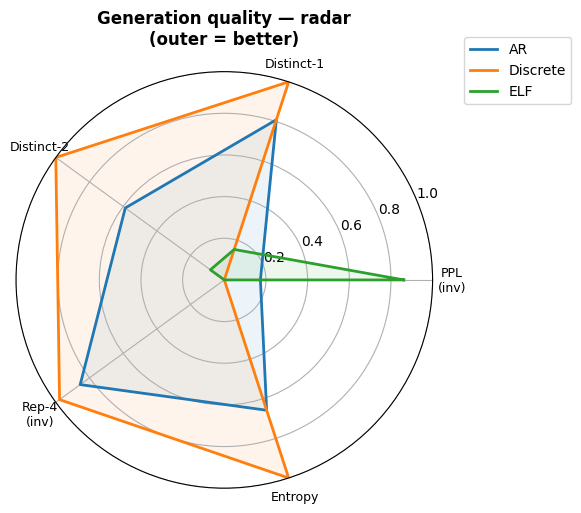

In [10]:
import matplotlib.pyplot as plt

summary = {}
for name in ('ar','discrete','elf'):
    lbl = {'ar':'AR','discrete':'Discrete','elf':'ELF'}[name]
    d   = dict(diversity.get(name,{}))
    if lbl in ppl_scores:     d['ppl']     = ppl_scores[lbl]
    if lbl in entropy_scores: d['entropy'] = entropy_scores[lbl]
    summary[lbl] = d
print(pd.DataFrame(summary).T.round(3).to_string())

labels = ['PPL\n(inv)','Distinct-1','Distinct-2','Rep-4\n(inv)','Entropy']
ps     = list(summary.keys())
colors = ['#1f77b4','#ff7f0e','#2ca02c']
raw    = [[summary[p].get('ppl',1) for p in ps],[summary[p].get('distinct_1',0) for p in ps],
          [summary[p].get('distinct_2',0) for p in ps],[summary[p].get('rep_4',0) for p in ps],
          [summary[p].get('entropy',0) for p in ps]]
inv = lambda v: [1-x/(max(v) or 1) for x in v]
nrm = lambda v: [x/(max(v) or 1) for x in v]
radar = [inv(raw[0]),nrm(raw[1]),nrm(raw[2]),inv(raw[3]),nrm(raw[4])]
N      = len(labels)
import math

angles = [n/N*2*math.pi for n in range(N)]+[0]
fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
for i,(lbl,col) in enumerate(zip(ps,colors)):
    v = [radar[m][i] for m in range(N)]+[radar[0][i]]
    ax.plot(angles,v,color=col,lw=2,label=lbl); ax.fill(angles,v,color=col,alpha=0.08)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(labels,size=9); ax.set_ylim(0,1)
ax.set_title('Generation quality — radar\n(outer = better)',pad=20,fontweight='bold')
ax.legend(loc='upper right',bbox_to_anchor=(1.35,1.1))
plt.tight_layout(); plt.show()

---

**Recap** — you learned:
- comparing paradigms fairly on one corpus and compute budget
- perplexity, distinct-n, rep-4, and output entropy
- reading the summary radar chart

**Next →** [11 · Attention Visualization](11_attention_visualization.ipynb) · [Open in Colab](https://colab.research.google.com/github/winstonsmith1897/DantinoX/blob/main/docs/notebooks/11_attention_visualization.ipynb)